# TS-SatFire -- HybridUNet v3 -- Inference

Runs the best checkpoint from the v3 training notebook on the held-out 2021 test set.
Produces per-fire and aggregate metrics, confusion breakdown, F1 distribution,
visual overlays, and a benchmark comparison chart.

Add the v3 weights dataset as input before running:
- `hybridunet_v3_ba_best.pt`
- `norm_stats_v3.npz`
- `run_meta_v3.json`
- `history_v3.json`

In [1]:
import os, sys, glob, json, random, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import distance_transform_edt
from tqdm.auto import tqdm
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {p.name}  {p.total_memory//1024**2} MB')

Python  : 3.12.12
PyTorch : 2.9.0+cu126
CUDA    : True
  GPU 0: Tesla T4  14912 MB
  GPU 1: Tesla T4  14912 MB


## Paths and config

In [2]:
DATA_ROOT   = '/kaggle/input/datasets/z789456sx/ts-satfire/ts-satfire'
OUTPUT_DIR  = '/kaggle/working'

# -- locate weights dataset --
# Try common Kaggle mount patterns and pick the one that exists
_candidates = [
    '/kaggle/input/datasets/con1los/hybridunetdataset',
    '/kaggle/input/malamus',
]
WEIGHTS_DIR = None
for _c in _candidates:
    if os.path.isdir(_c):
        WEIGHTS_DIR = _c
        break
if WEIGHTS_DIR is None:
    # Fall back: search /kaggle/input for the checkpoint file
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'hybridunet_v3_ba_best.pt' in files:
            WEIGHTS_DIR = root
            break
if WEIGHTS_DIR is None:
    raise RuntimeError(
        'Cannot find weights. Run the diagnostic below to find the mount path:\n'
        'import os\n'
        'for r,d,f in os.walk("/kaggle/input"):\n'
        '    for fi in f: print(os.path.join(r,fi))'
    )
print(f'Weights dir : {WEIGHTS_DIR}')

CKPT_PATH  = os.path.join(WEIGHTS_DIR, 'hybridunet_v3_ba_best.pt')
STATS_PATH = os.path.join(WEIGHTS_DIR, 'norm_stats_v3.npz')
META_PATH  = os.path.join(WEIGHTS_DIR, 'run_meta_v3.json')
HIST_PATH  = os.path.join(WEIGHTS_DIR, 'history_v3.json')

for p in [CKPT_PATH, STATS_PATH, META_PATH, HIST_PATH]:
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  [{status}]  {p}')

with open(META_PATH) as f:
    meta = json.load(f)

TIME_STEPS        = meta['TIME_STEPS']
CHANS_PER_STEP    = 26
IN_CHANNELS       = CHANS_PER_STEP * TIME_STEPS
PATCH_SIZE        = meta['PATCH_SIZE']
BASE_CH           = meta['BASE_CH']
N_HEADS           = meta['N_HEADS']
BOTTLENECK        = meta.get('BOTTLENECK', 16)
INFER_THRESHOLD   = meta.get('INFER_THRESHOLD', 0.55)
FIRE_CLASS_WEIGHT = meta['FIRE_CLASS_WEIGHT']
FOCAL_GAMMA       = meta['FOCAL_GAMMA']
DIST_MAX_PX       = meta.get('DIST_MAX_PX', 50)
DIST_SIGMA        = meta.get('DIST_SIGMA', 5.0)
VAL_INTERVAL      = 4
SEED              = 42
SAVE_FIGURES      = True

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_autocast():
    return torch.amp.autocast('cuda') if device.type == 'cuda'            else torch.amp.autocast('cpu', dtype=torch.float32)

print(f'\nDevice            : {device}')
print(f'TIME_STEPS        : {TIME_STEPS}')
print(f'IN_CHANNELS       : {IN_CHANNELS}')
print(f'PATCH_SIZE        : {PATCH_SIZE}')
print(f'BOTTLENECK        : {BOTTLENECK}')
print(f'INFER_THRESHOLD   : {INFER_THRESHOLD}')
print(f'FIRE_CLASS_WEIGHT : {FIRE_CLASS_WEIGHT}')
print(f'Best val mF1      : {meta.get("best_val_mf1", "n/a")}')

Weights dir : /kaggle/input/datasets/con1los/hybridunetdataset
  [OK]  /kaggle/input/datasets/con1los/hybridunetdataset/hybridunet_v3_ba_best.pt
  [OK]  /kaggle/input/datasets/con1los/hybridunetdataset/norm_stats_v3.npz
  [OK]  /kaggle/input/datasets/con1los/hybridunetdataset/run_meta_v3.json
  [OK]  /kaggle/input/datasets/con1los/hybridunetdataset/history_v3.json

Device            : cuda
TIME_STEPS        : 2
IN_CHANNELS       : 52
PATCH_SIZE        : 128
BOTTLENECK        : 16
INFER_THRESHOLD   : 0.55
FIRE_CLASS_WEIGHT : 300.0
Best val mF1      : 0.25319624730126583


## Dataset splits (replicated from training)

In [3]:
if not os.path.isdir(DATA_ROOT):
    raise RuntimeError(f'Dataset not found at {DATA_ROOT}')

all_dirs = sorted([d for d in glob.glob(os.path.join(DATA_ROOT,'*')) if os.path.isdir(d)])
REQUIRED = {'VIIRS_Day','VIIRS_Night','FirePred'}
fire_dirs = [d for d in all_dirs if REQUIRED.issubset(set(os.listdir(d)))]

def fp_chan_count(fd):
    files = sorted(glob.glob(os.path.join(fd,'FirePred','*.tif')))
    if not files: return -1
    with rasterio.open(files[0]) as src: return src.count

fire_dirs = [fd for fd in fire_dirs if fp_chan_count(fd) == 19]

# Replicate exact split from training using stored fire IDs
train_ids = set(meta['train_fires'])
val_ids   = set(meta['val_fires'])
test_ids  = set(meta['test_fires'])

test_fires  = [fd for fd in fire_dirs if os.path.basename(fd) in test_ids]
train_fires = [fd for fd in fire_dirs if os.path.basename(fd) in train_ids]
val_fires   = [fd for fd in fire_dirs if os.path.basename(fd) in val_ids]

print(f'Usable fires : {len(fire_dirs)}')
print(f'  train : {len(train_fires)}')
print(f'  val   : {len(val_fires)}')
print(f'  test  : {len(test_fires)}')
print(f'Test fires not found: {test_ids - set(os.path.basename(f) for f in test_fires)}')

Usable fires : 173
  train : 127
  val   : 22
  test  : 24
Test fires not found: set()


## Normalisation statistics

In [4]:
data       = np.load(STATS_PATH)
CHAN_MEANS  = data['means']
CHAN_STDS   = data['stds']
CLIP_LO     = data['clip_lo']
CLIP_HI     = data['clip_hi']
print(f'Loaded normalisation stats from {STATS_PATH}')
print(f'Means range : [{CHAN_MEANS.min():.3f}, {CHAN_MEANS.max():.3f}]')
print(f'Stds  range : [{CHAN_STDS.min():.3f},  {CHAN_STDS.max():.3f}]')

Loaded normalisation stats from /kaggle/input/datasets/con1los/hybridunetdataset/norm_stats_v3.npz
Means range : [-0.123, 4260.868]
Stds  range : [0.002,  2406.180]


## Dataset and DataLoader

In [5]:
def make_distance_weight_map(label_np, max_dist=DIST_MAX_PX, sigma=DIST_SIGMA):
    burned = (label_np > 0).astype(np.uint8)
    if burned.sum() == 0:
        return np.ones_like(label_np, dtype=np.float32)
    dist = distance_transform_edt(1 - burned).astype(np.float32)
    dist = np.clip(dist, 0.0, float(max_dist)) / float(max_dist)
    weight_map = 1.0 + dist * sigma
    weight_map[burned == 1] = 1.0
    return weight_map.astype(np.float32)


class TSSatFireDataset(Dataset):
    def __init__(self, fire_dirs, time_steps=TIME_STEPS, interval=1,
                 patch_size=None, means=None, stds=None,
                 clip_lo=None, clip_hi=None):
        self.T          = time_steps
        self.interval   = interval
        self.patch_size = patch_size
        self.means      = means
        self.stds       = stds
        self.clip_lo    = clip_lo
        self.clip_hi    = clip_hi
        self.samples    = []
        self._build_index(fire_dirs)

    def _build_index(self, fire_dirs):
        skipped = 0
        for fd in fire_dirs:
            fp_files  = sorted(glob.glob(os.path.join(fd,'FirePred','*.tif')))
            day_files = sorted(glob.glob(os.path.join(fd,'VIIRS_Day','*.tif')))
            if not fp_files or not day_files or len(day_files) < self.T:
                skipped += 1; continue
            n = len(day_files)
            start = 0
            while start + self.T <= n:
                self.samples.append({
                    'fire_dir' : fd,
                    'day_files': day_files,
                    'start'    : start,
                    'end'      : start + self.T - 1,
                })
                start += self.interval
        print(f'Dataset: {len(self.samples)} samples (skipped={skipped})')

    @staticmethod
    def _date(path):
        return os.path.basename(path).replace('_VIIRS_Day.tif','')

    def _load_timestep(self, fd, day_path, H, W):
        date_str   = self._date(day_path)
        night_path = os.path.join(fd,'VIIRS_Night',f'{date_str}_VIIRS_Night.tif')
        fp_path    = os.path.join(fd,'FirePred',   f'{date_str}_FirePred.tif')
        with rasterio.open(day_path) as src:
            day_arr = src.read().astype(np.float32)
        spectral = day_arr[:6,:H,:W]
        if os.path.exists(night_path):
            with rasterio.open(night_path) as src:
                night = src.read().astype(np.float32)[:2,:H,:W]
        else:
            night = np.full((2,H,W), np.nan, np.float32)
        if os.path.exists(fp_path):
            with rasterio.open(fp_path) as src:
                fp = src.read().astype(np.float32)
            if fp.shape[1]!=H or fp.shape[2]!=W:
                fp = F.interpolate(torch.from_numpy(fp).unsqueeze(0),
                                   size=(H,W),mode='nearest').squeeze(0).numpy()
            aux = np.concatenate([fp[:2],fp[3:]],axis=0)
        else:
            aux = np.zeros((18,H,W),np.float32)
        return np.concatenate([spectral,night,aux],axis=0)

    def _load_label(self, fd, day_path, H, W):
        date_str = self._date(day_path)
        fp_path  = os.path.join(fd,'FirePred',f'{date_str}_FirePred.tif')
        if os.path.exists(fp_path):
            with rasterio.open(fp_path) as src:
                ch2 = src.read(3).astype(np.float32)
            if ch2.shape[0]!=H or ch2.shape[1]!=W:
                ch2 = F.interpolate(torch.from_numpy(ch2).unsqueeze(0).unsqueeze(0),
                                    size=(H,W),mode='nearest').squeeze().numpy()
            return (ch2>0).astype(np.float32)
        return np.zeros((H,W),np.float32)

    def _thermal_cummax(self, fd, all_day_files, win_end, H, W):
        history = []
        for i in range(win_end+1):
            dp       = all_day_files[i]
            date_str = self._date(dp)
            np_path  = os.path.join(fd,'VIIRS_Night',f'{date_str}_VIIRS_Night.tif')
            with rasterio.open(dp) as src:
                i4d = src.read(4).astype(np.float32)[:H,:W]
                i5d = src.read(5).astype(np.float32)[:H,:W]
            if os.path.exists(np_path):
                with rasterio.open(np_path) as src:
                    i4n = src.read(1).astype(np.float32)[:H,:W]
                    i5n = src.read(2).astype(np.float32)[:H,:W]
            else:
                i4n = np.full((H,W),np.nan,np.float32)
                i5n = np.full((H,W),np.nan,np.float32)
            history.append(np.stack([i4d,i5d,i4n,i5n]))
        return history

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s         = self.samples[idx]
        fd        = s['fire_dir']
        all_files = s['day_files']
        win_start = s['start']
        win_end   = s['end']
        win_files = all_files[win_start:win_end+1]
        shapes    = []
        for dp in win_files:
            with rasterio.open(dp) as src: shapes.append((src.height,src.width))
        H = min(sh[0] for sh in shapes)
        W = min(sh[1] for sh in shapes)
        frames  = [self._load_timestep(fd,dp,H,W) for dp in win_files]
        history = self._thermal_cummax(fd,all_files,win_end,H,W)
        for t in range(self.T):
            gd  = win_start+t
            cmx = np.nanmax(np.stack(history[:gd+1]),axis=0)
            frames[t][3]=cmx[0]; frames[t][4]=cmx[1]
            frames[t][6]=cmx[2]; frames[t][7]=cmx[3]
        stack = np.stack(frames,axis=0)
        if self.clip_lo is not None:
            stack = np.clip(stack,
                            self.clip_lo[None,:,None,None],
                            self.clip_hi[None,:,None,None])
        if self.means is not None:
            stack = (stack - self.means[None,:,None,None]) /                      self.stds[ None,:,None,None]
        stack = np.nan_to_num(stack,nan=0.0,posinf=0.0,neginf=0.0)
        label = self._load_label(fd,win_files[-1],H,W)
        if self.patch_size and H>self.patch_size and W>self.patch_size:
            r = random.randint(0,H-self.patch_size)
            c = random.randint(0,W-self.patch_size)
            p = self.patch_size
            stack = stack[:,:,r:r+p,c:c+p]
            label = label[r:r+p,c:c+p]
        dist_weight = make_distance_weight_map(label)
        x = torch.from_numpy(stack.reshape(-1,stack.shape[2],stack.shape[3])).float()
        y = torch.from_numpy(label).long()
        w = torch.from_numpy(dist_weight).float()
        return x, y, w

test_ds = TSSatFireDataset(
    fire_dirs  = test_fires,
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,
    patch_size = None,
    means      = CHAN_MEANS, stds=CHAN_STDS,
    clip_lo    = CLIP_LO,   clip_hi=CLIP_HI,
)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                         num_workers=0, pin_memory=True)
print(f'Test samples : {len(test_ds)}')

Dataset: 220 samples (skipped=0)
Test samples : 220


## Model

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch,out_ch,3,padding=1,bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch,out_ch,3,padding=1,bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout>0: layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)
    def forward(self,x): return self.net(x)

class TemporalMLP(nn.Module):
    def __init__(self, chans_per_step=CHANS_PER_STEP, time_steps=TIME_STEPS,
                 bottleneck=BOTTLENECK, dropout=0.1):
        super().__init__()
        self.T=time_steps; self.C=chans_per_step
        self.fc1=nn.Conv1d(time_steps,bottleneck,1,bias=False)
        self.act=nn.GELU(); self.drop=nn.Dropout(dropout)
        self.fc2=nn.Conv1d(bottleneck,time_steps,1,bias=False)
        self.norm=nn.LayerNorm(chans_per_step)
    def forward(self,x):
        B,TC,H,W=x.shape
        xr=x.view(B,self.T,self.C,H,W).permute(0,3,4,1,2).reshape(B*H*W,self.T,self.C)
        xr=self.norm(xr).transpose(1,2)
        N,C,T=xr.shape
        xr=xr.reshape(N,C,T).permute(0,2,1)
        res=xr; xr=self.fc2(self.drop(self.act(self.fc1(xr))))+res
        xr=xr.permute(0,2,1).reshape(B,H,W,C,T).permute(0,4,3,1,2)
        return xr.reshape(B,TC,H,W)

class SpatialTransformerBlock(nn.Module):
    def __init__(self, dim, n_heads=N_HEADS, dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(dim)
        self.attn=nn.MultiheadAttention(dim,n_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(dim)
        self.ff=nn.Sequential(nn.Linear(dim,dim*4),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(dim*4,dim),nn.Dropout(dropout))
    def forward(self,x):
        B,C,H,W=x.shape
        seq=x.flatten(2).transpose(1,2)
        seq=seq+self.attn(*[self.norm1(seq)]*3)[0]
        seq=seq+self.ff(self.norm2(seq))
        return seq.transpose(1,2).reshape(B,C,H,W)

class HybridUNetV3(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, out_channels=2,
                 base_ch=BASE_CH, n_heads=N_HEADS):
        super().__init__()
        b=base_ch
        self.temporal_mlp=TemporalMLP(CHANS_PER_STEP,TIME_STEPS,BOTTLENECK,0.1)
        self.enc1=DoubleConv(in_channels,b)
        self.enc2=DoubleConv(b,b*2)
        self.enc3=DoubleConv(b*2,b*4,dropout=0.1)
        self.enc4=DoubleConv(b*4,b*8,dropout=0.1)
        self.pool=nn.MaxPool2d(2)
        self.bottleneck_conv=DoubleConv(b*8,b*16,dropout=0.1)
        self.bottleneck_attn=SpatialTransformerBlock(b*16,n_heads)
        self.up4=nn.ConvTranspose2d(b*16,b*8,2,stride=2)
        self.up3=nn.ConvTranspose2d(b*8,b*4,2,stride=2)
        self.up2=nn.ConvTranspose2d(b*4,b*2,2,stride=2)
        self.up1=nn.ConvTranspose2d(b*2,b,2,stride=2)
        self.dec4=DoubleConv(b*16,b*8); self.dec3=DoubleConv(b*8,b*4)
        self.dec2=DoubleConv(b*4,b*2);  self.dec1=DoubleConv(b*2,b)
        self.head=nn.Conv2d(b,out_channels,1)
    def _pad_cat(self,up,skip):
        if up.shape!=skip.shape:
            up=F.interpolate(up,size=skip.shape[2:],mode='bilinear',align_corners=False)
        return torch.cat([up,skip],dim=1)
    def forward(self,x):
        x=self.temporal_mlp(x)
        e1=self.enc1(x); e2=self.enc2(self.pool(e1))
        e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck_conv(self.pool(e4)); b=self.bottleneck_attn(b)
        d4=self.dec4(self._pad_cat(self.up4(b),e4))
        d3=self.dec3(self._pad_cat(self.up3(d4),e3))
        d2=self.dec2(self._pad_cat(self.up2(d3),e2))
        d1=self.dec1(self._pad_cat(self.up1(d2),e1))
        return self.head(d1)

eval_model = HybridUNetV3(in_channels=IN_CHANNELS, out_channels=2,
                           base_ch=BASE_CH, n_heads=N_HEADS)
state = torch.load(CKPT_PATH, map_location=device)
eval_model.load_state_dict(state)
eval_model = eval_model.to(device).eval()

n_params = sum(p.numel() for p in eval_model.parameters())
print(f'Loaded checkpoint : {CKPT_PATH}')
print(f'Parameters        : {n_params:,}')

with torch.no_grad():
    dummy = torch.zeros(1, IN_CHANNELS, 128, 128, device=device)
    out   = eval_model(dummy)
print(f'Dry run : {tuple(dummy.shape)} -> {tuple(out.shape)}')

Loaded checkpoint : /kaggle/input/datasets/con1los/hybridunetdataset/hybridunet_v3_ba_best.pt
Parameters        : 10,929,686
Dry run : (1, 52, 128, 128) -> (1, 2, 128, 128)


## Inference

In [7]:
def pad_to_multiple(x, m=16):
    _,_,h,w = x.shape
    ph = (m - h%m) % m
    pw = (m - w%m) % m
    return F.pad(x,(0,pw,0,ph)), h, w


tp_total = fp_total = fn_total = 0
per_sample_f1   = []
per_fire_results = {os.path.basename(fd): {'tp':0,'fp':0,'fn':0,'n_days':0}
                    for fd in test_fires}

eval_model.eval()
with torch.no_grad():
    for idx, (x, y, w) in enumerate(tqdm(test_loader, desc='Inference')):
        x = x.to(device)
        xp, H_orig, W_orig = pad_to_multiple(x)
        with make_autocast():
            logits = eval_model(xp)
        logits = logits[:, :, :H_orig, :W_orig]
        prob   = torch.softmax(logits.float(), dim=1)[:, 1]
        pred   = (prob > INFER_THRESHOLD).long().cpu()
        tgt    = (y == 1).long()

        tp_i = int((pred * tgt).sum())
        fp_i = int((pred * (1-tgt)).sum())
        fn_i = int(((1-pred) * tgt).sum())
        f1_i = 2*tp_i / (2*tp_i + fp_i + fn_i + 1e-6)

        tp_total += tp_i; fp_total += fp_i; fn_total += fn_i
        per_sample_f1.append(f1_i)

        # Attribute to fire
        s      = test_ds.samples[idx]
        fid    = os.path.basename(s['fire_dir'])
        if fid in per_fire_results:
            per_fire_results[fid]['tp'] += tp_i
            per_fire_results[fid]['fp'] += fp_i
            per_fire_results[fid]['fn'] += fn_i
            per_fire_results[fid]['n_days'] += 1

global_f1  = 2*tp_total / (2*tp_total + fp_total + fn_total + 1e-6)
global_iou = tp_total   / (tp_total + fp_total + fn_total + 1e-6)
mean_f1    = float(np.mean(per_sample_f1))

print(f'\nTest results (v3):')
print(f'  Global F1   : {global_f1:.4f}')
print(f'  Global IoU  : {global_iou:.4f}')
print(f'  Mean F1     : {mean_f1:.4f}')
print(f'  TP={tp_total:,}  FP={fp_total:,}  FN={fn_total:,}')
print(f'  FP/FN ratio : {fp_total/(fn_total+1e-6):.2f}  (v2 was 8.79)')

results = {
    'F1': global_f1, 'IoU': global_iou,
    'mean_F1': mean_f1,
    'TP': tp_total, 'FP': fp_total, 'FN': fn_total,
    'n_samples': len(per_sample_f1),
    'n_fires'  : len(test_fires),
    'threshold': INFER_THRESHOLD,
}
with open(os.path.join(OUTPUT_DIR, 'test_results_v3.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved test_results_v3.json')

Inference:   0%|          | 0/220 [00:00<?, ?it/s]


Test results (v3):
  Global F1   : 0.4850
  Global IoU  : 0.3202
  Mean F1     : 0.2404
  TP=12,253,742  FP=25,632,047  FN=388,518
  FP/FN ratio : 65.97  (v2 was 8.79)
Saved test_results_v3.json


## Per-fire results

In [8]:
fire_rows = []
for fid, r in per_fire_results.items():
    tp,fp,fn = r['tp'],r['fp'],r['fn']
    f1  = 2*tp / (2*tp+fp+fn+1e-6)
    iou = tp   / (tp+fp+fn+1e-6)
    fire_rows.append({'fire_id':fid,'F1':round(f1,4),'IoU':round(iou,4),
                      'TP':tp,'FP':fp,'FN':fn,'n_days':r['n_days']})

df_fire = pd.DataFrame(fire_rows).sort_values('F1',ascending=False)
print(df_fire.to_string(index=False))
df_fire.to_csv(os.path.join(OUTPUT_DIR,'per_fire_results_v3.csv'), index=False)

                      fire_id     F1    IoU      TP      FP    FN  n_days
US_2021_NM3340210587120210426 0.9839 0.9682  343933       0 11288       3
US_2021_CA3568711855020210818 0.8803 0.7862  233689   59594  3950       6
US_2021_NM3344410803520210514 0.7557 0.6073  164180   69139 37027       6
US_2021_AZ3368910927620210616 0.7220 0.5649  824652  608200 26973       6
US_2021_AZ3345510938920210616 0.6966 0.5345  585348  483086 26705       5
US_2021_ID4762711608320210708 0.6425 0.4732 1248000 1347533 41589      15
US_2021_CA3658211879520210912 0.6082 0.4370  608796  714235 70147      13
US_2021_NM3676810505920211120 0.6053 0.4340  587451  765246   737       7
US_2021_MT4568311385420210708 0.5990 0.4275 2509442 3354865  5524      19
US_2021_NM3323810847220210520 0.5918 0.4203  323529  404918 41316      10
US_2021_WA4879111827120210805 0.5661 0.3948  531027  804126 10058       7
US_2021_WA4828511853120210713 0.5342 0.3644  989644 1692640 33225      17
US_2021_MT4714310953420211004 0.5203 0

## F1 distribution and FP/FN analysis

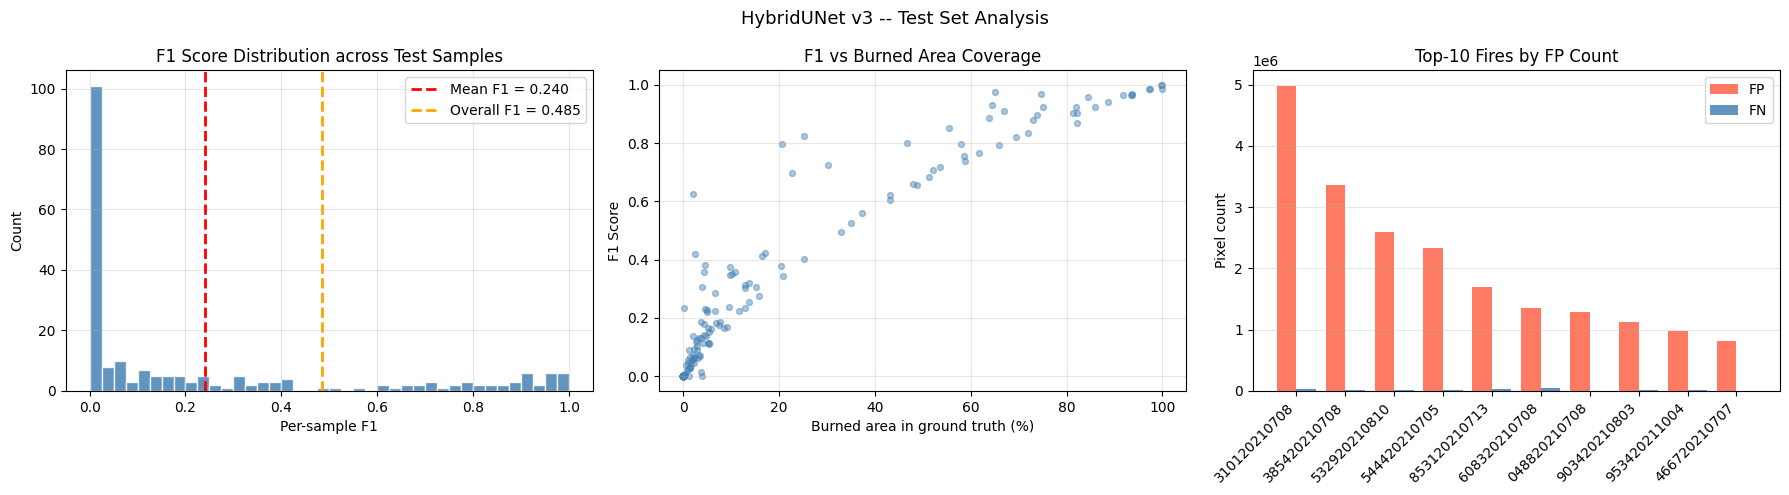

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# F1 histogram
axes[0].hist(per_sample_f1, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mean_f1,   color='red',    linestyle='--', linewidth=2,
                label=f'Mean F1 = {mean_f1:.3f}')
axes[0].axvline(global_f1, color='orange', linestyle='--', linewidth=2,
                label=f'Overall F1 = {global_f1:.3f}')
axes[0].set_xlabel('Per-sample F1')
axes[0].set_ylabel('Count')
axes[0].set_title('F1 Score Distribution across Test Samples')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs burned area coverage
ba_coverages = []
for s in test_ds.samples:
    fd  = s['fire_dir']
    win_files = s['day_files'][s['start']:s['end']+1]
    date_str  = os.path.basename(win_files[-1]).replace('_VIIRS_Day.tif','')
    fp_path   = os.path.join(fd,'FirePred',f'{date_str}_FirePred.tif')
    if os.path.exists(fp_path):
        with rasterio.open(fp_path) as src:
            lbl = (src.read(3) > 0).astype(np.float32)
        ba_coverages.append(float(lbl.mean()) * 100)
    else:
        ba_coverages.append(0.0)

axes[1].scatter(ba_coverages, per_sample_f1, alpha=0.45, s=18, color='steelblue')
axes[1].set_xlabel('Burned area in ground truth (%)')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Burned Area Coverage')
axes[1].grid(True, alpha=0.3)

# FP/FN per fire
df_sorted = df_fire.sort_values('FP', ascending=False).head(10)
x_pos = np.arange(len(df_sorted))
axes[2].bar(x_pos - 0.2, df_sorted['FP'], 0.4, label='FP', color='tomato',   alpha=0.85)
axes[2].bar(x_pos + 0.2, df_sorted['FN'], 0.4, label='FN', color='steelblue',alpha=0.85)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([fid[-12:] for fid in df_sorted['fire_id']], rotation=45, ha='right')
axes[2].set_ylabel('Pixel count')
axes[2].set_title('Top-10 Fires by FP Count')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('HybridUNet v3 -- Test Set Analysis', fontsize=13)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR,'f1_distribution_v3.png'), dpi=150, bbox_inches='tight')
plt.show()

## Benchmark comparison (v2 vs v3 vs paper)

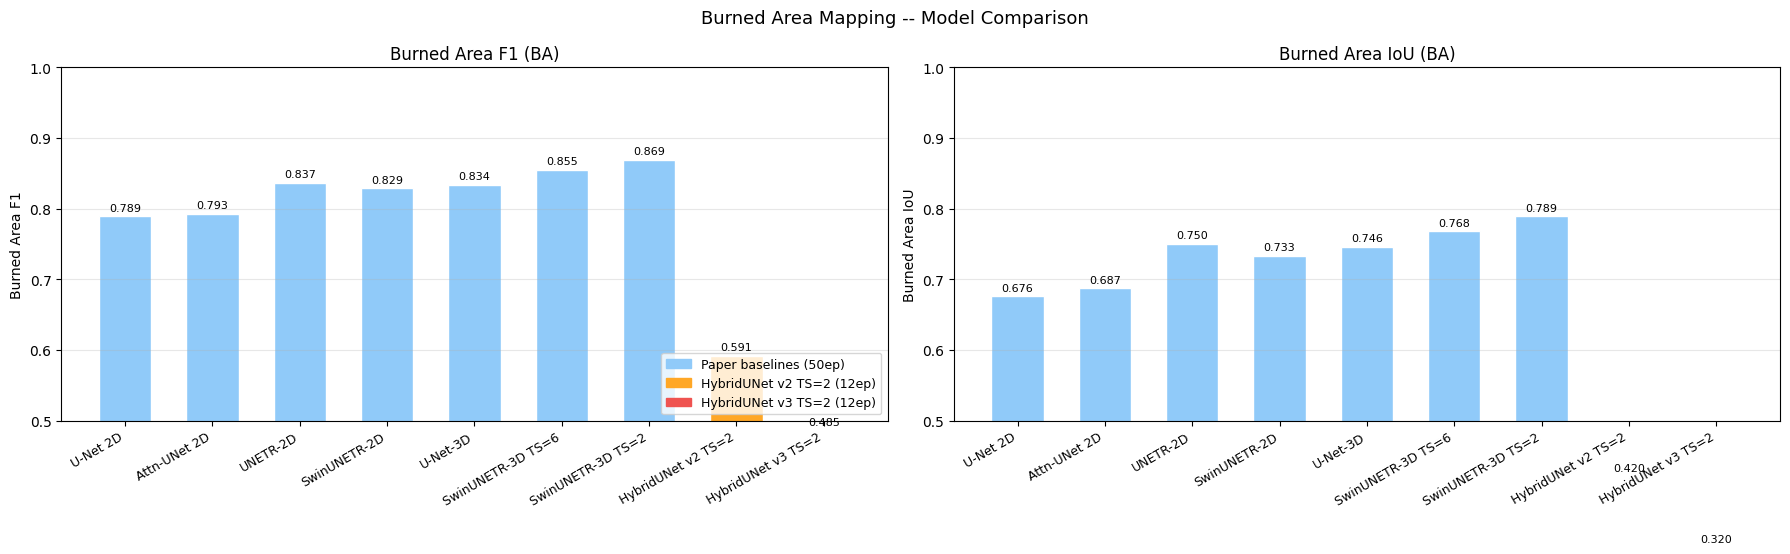


Summary:
  v2  F1=0.5914  IoU=0.4199
  v3  F1=0.4850  IoU=0.3202
  Delta  F1=-0.1064  IoU=-0.0997


In [10]:
with open(HIST_PATH) as f:
    history = json.load(f)

# v2 test results -- hardcoded from previous inference run
v2_f1  = 0.5914
v2_iou = 0.4199

paper_baselines = {
    'U-Net 2D':           (0.789, 0.676),
    'Attn-UNet 2D':       (0.793, 0.687),
    'UNETR-2D':           (0.837, 0.750),
    'SwinUNETR-2D':       (0.829, 0.733),
    'U-Net-3D':           (0.834, 0.746),
    'SwinUNETR-3D TS=6':  (0.855, 0.768),
    'SwinUNETR-3D TS=2':  (0.869, 0.789),
}

labels  = list(paper_baselines.keys()) + ['HybridUNet v2 TS=2', 'HybridUNet v3 TS=2']
f1s     = [v[0] for v in paper_baselines.values()] + [v2_f1,  global_f1]
ious    = [v[1] for v in paper_baselines.values()] + [v2_iou, global_iou]
colors  = ['#90CAF9']*len(paper_baselines) + ['#FFA726', '#EF5350']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(labels))
for ax, vals, title, paper_best in zip(
        axes, [f1s, ious],
        ['Burned Area F1 (BA)', 'Burned Area IoU (BA)'],
        [0.869, 0.789]):
    bars = ax.bar(x, vals, color=colors, edgecolor='white', width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel(title.split('(')[0].strip())
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')

legend_patches = [
    mpatches.Patch(color='#90CAF9', label='Paper baselines (50ep)'),
    mpatches.Patch(color='#FFA726', label='HybridUNet v2 TS=2 (12ep)'),
    mpatches.Patch(color='#EF5350', label='HybridUNet v3 TS=2 (12ep)'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.suptitle('Burned Area Mapping -- Model Comparison', fontsize=13)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR,'benchmark_comparison_v3.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSummary:')
print(f'  v2  F1={v2_f1:.4f}  IoU={v2_iou:.4f}')
print(f'  v3  F1={global_f1:.4f}  IoU={global_iou:.4f}')
delta_f1  = global_f1 - v2_f1
delta_iou = global_iou - v2_iou
print(f'  Delta  F1={delta_f1:+.4f}  IoU={delta_iou:+.4f}')

## Training history

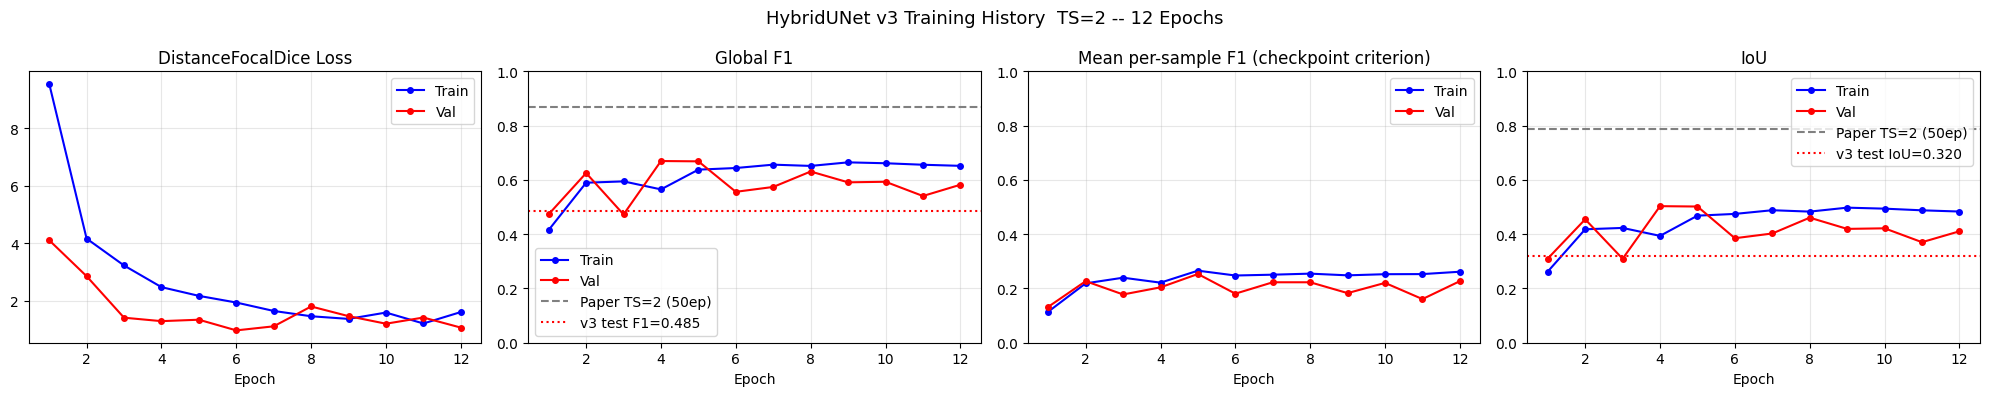

In [11]:
epochs = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(epochs, history['train_loss'],'b-o',label='Train',markersize=4)
axes[0].plot(epochs, history['val_loss'],  'r-o',label='Val',  markersize=4)
axes[0].set_title('DistanceFocalDice Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_F1'],'b-o',label='Train',markersize=4)
axes[1].plot(epochs, history['val_F1'],  'r-o',label='Val',  markersize=4)
axes[1].axhline(0.869,color='gray',linestyle='--',linewidth=1.5,label='Paper TS=2 (50ep)')
axes[1].axhline(global_f1,color='red',linestyle=':',linewidth=1.5,label=f'v3 test F1={global_f1:.3f}')
axes[1].set_title('Global F1'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0,1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['train_mF1'],'b-o',label='Train',markersize=4)
axes[2].plot(epochs, history['val_mF1'],  'r-o',label='Val',  markersize=4)
axes[2].set_title('Mean per-sample F1 (checkpoint criterion)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0,1)
axes[2].legend(); axes[2].grid(True, alpha=0.3)

axes[3].plot(epochs, history['train_IoU'],'b-o',label='Train',markersize=4)
axes[3].plot(epochs, history['val_IoU'],  'r-o',label='Val',  markersize=4)
axes[3].axhline(0.789,color='gray',linestyle='--',linewidth=1.5,label='Paper TS=2 (50ep)')
axes[3].axhline(global_iou,color='red',linestyle=':',linewidth=1.5,label=f'v3 test IoU={global_iou:.3f}')
axes[3].set_title('IoU'); axes[3].set_xlabel('Epoch')
axes[3].set_ylim(0,1); axes[3].legend(); axes[3].grid(True, alpha=0.3)

plt.suptitle(f'HybridUNet v3 Training History  TS=2 -- 12 Epochs', fontsize=13)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR,'training_curves_v3_with_test.png'),dpi=150,bbox_inches='tight')
plt.show()

## Visual examples (best and worst fires)

Plotting fires: ['US_2021_AZ3368910927620210616', 'US_2021_ID4453211532920210810', 'US_2021_CA3604711863120210910', 'US_2021_MT4579011310120210708', 'US_2021_ID4663811466720210707', 'US_2021_CA3568711855020210818']


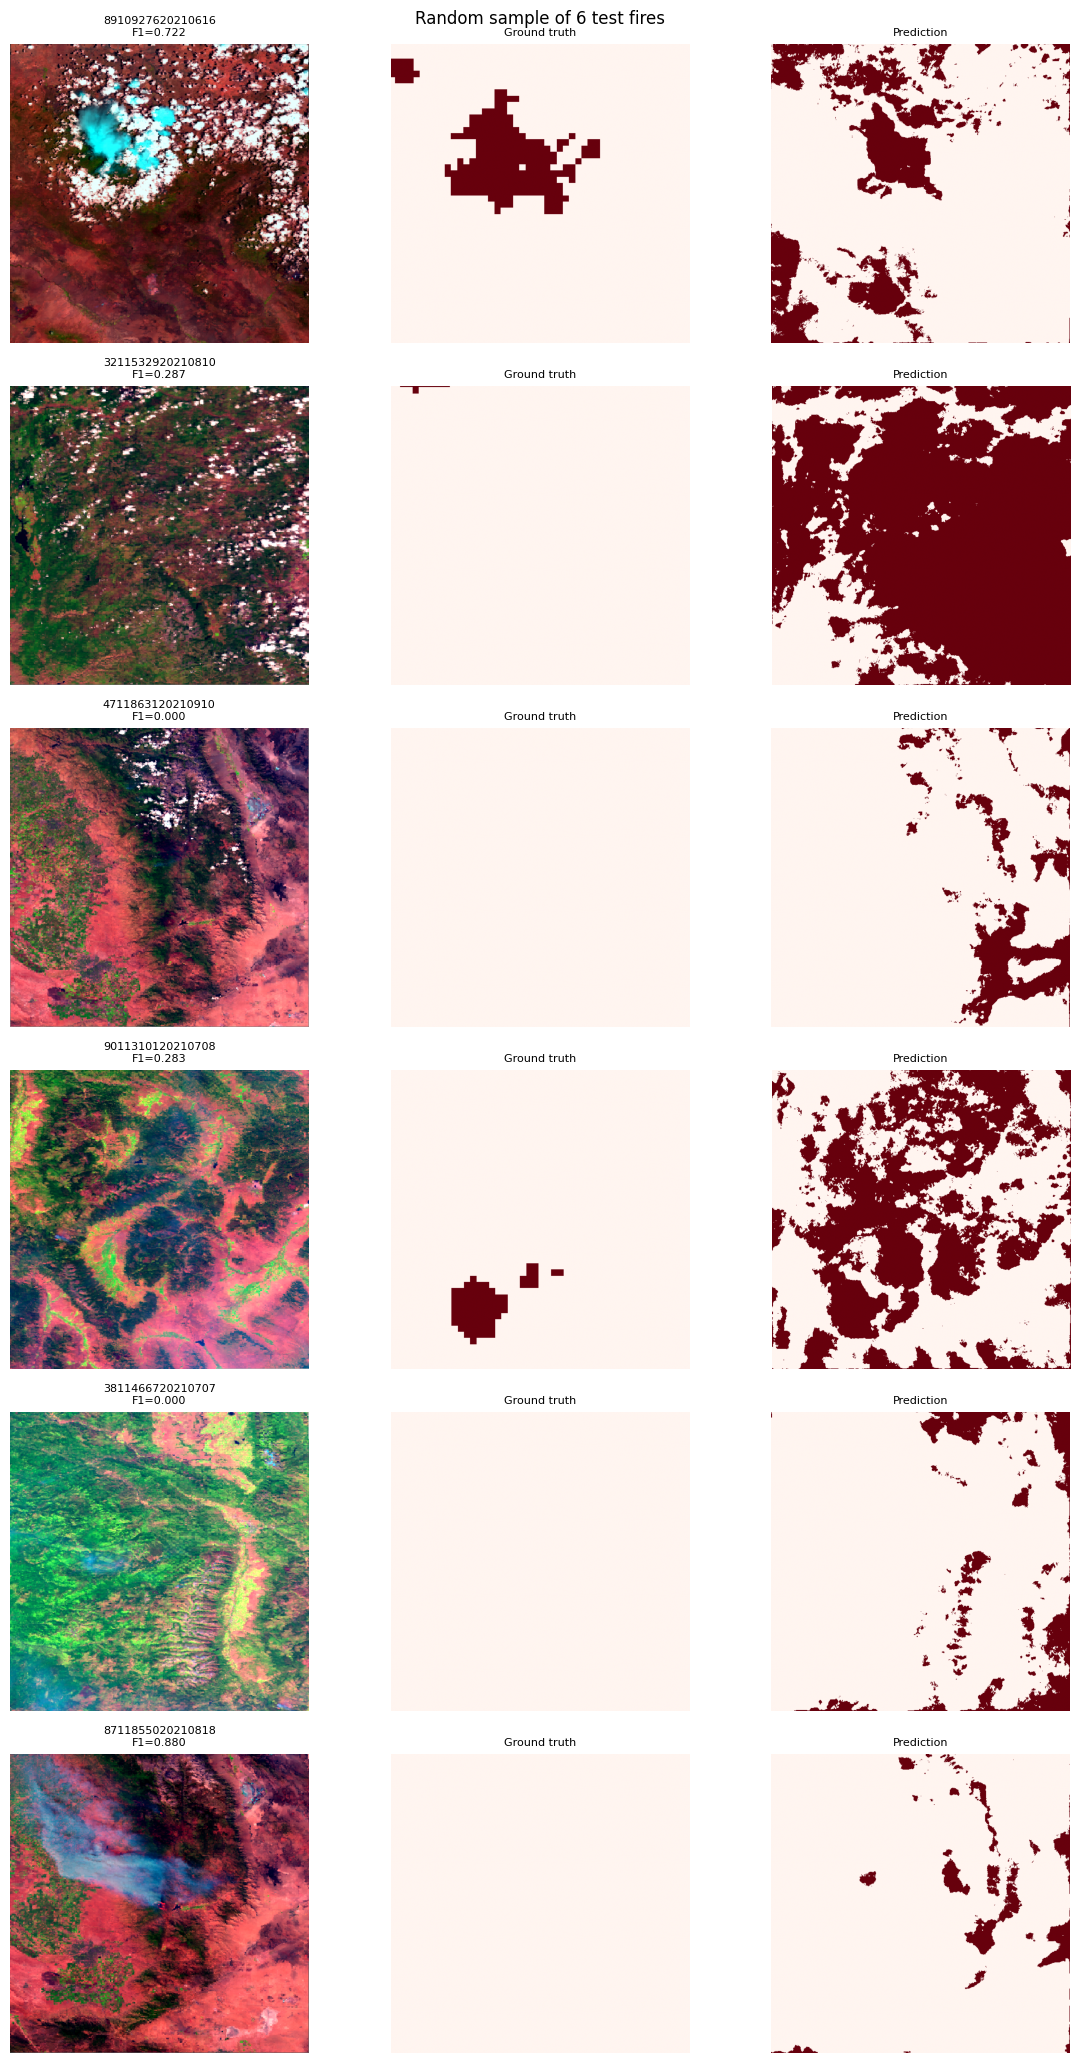

In [14]:
def get_rgb(x_tensor):
    """Return a displayable RGB from bands I1(0), I2(1), I3(2) of the last timestep."""
    arr = x_tensor.squeeze(0).cpu().numpy()
    offset = (TIME_STEPS - 1) * CHANS_PER_STEP
    r = arr[offset + 2]; g = arr[offset + 1]; b = arr[offset + 0]
    rgb = np.stack([r, g, b], axis=-1)
    lo, hi = np.percentile(rgb, 2), np.percentile(rgb, 98)
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)
    return rgb


# Build a map from fire_id -> first sample index in test_ds
fid_to_idx = {}
for idx, s in enumerate(test_ds.samples):
    fid = os.path.basename(s['fire_dir'])
    if fid not in fid_to_idx:
        fid_to_idx[fid] = idx

# Random sample of 6 fires that actually have samples
available_fids = list(fid_to_idx.keys())
random.seed(SEED + 1)
random_fires = random.sample(available_fids, min(6, len(available_fids)))
print(f'Plotting fires: {random_fires}')

fig, axes = plt.subplots(len(random_fires), 3, figsize=(12, len(random_fires) * 3.5))
if len(random_fires) == 1:
    axes = axes[None]

eval_model.eval()
with torch.no_grad():
    for row, fid in enumerate(random_fires):
        idx    = fid_to_idx[fid]
        x, y, w = test_ds[idx]
        x = x.unsqueeze(0).to(device)

        xp, H_orig, W_orig = pad_to_multiple(x)
        with make_autocast():
            logits = eval_model(xp)
        logits = logits[:, :, :H_orig, :W_orig]
        prob   = torch.softmax(logits.float(), dim=1)[:, 1]
        pred   = (prob > INFER_THRESHOLD).long().cpu().squeeze().numpy()
        lbl    = y.numpy()
        rgb    = get_rgb(x.cpu())

        f1_vals = df_fire[df_fire['fire_id'] == fid]['F1'].values
        f1_val  = f1_vals[0] if len(f1_vals) > 0 else float('nan')

        axes[row, 0].imshow(rgb);                             axes[row, 0].axis('off')
        axes[row, 0].set_title(f'{fid[-16:]}\nF1={f1_val:.3f}', fontsize=8)
        axes[row, 1].imshow(lbl,  cmap='Reds', vmin=0, vmax=1); axes[row, 1].axis('off')
        axes[row, 1].set_title('Ground truth', fontsize=8)
        axes[row, 2].imshow(pred, cmap='Reds', vmin=0, vmax=1); axes[row, 2].axis('off')
        axes[row, 2].set_title('Prediction', fontsize=8)

plt.suptitle('Random sample of 6 test fires', fontsize=12)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'visual_random_v3.png'), dpi=150, bbox_inches='tight')
plt.show()

## Output files

In [15]:
print('Inference complete.')
print('='*60)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath)
    unit  = 'KB' if size < 1024**2 else 'MB'
    val   = size/1024 if unit=='KB' else size/1024**2
    print(f'  {fname:<55}  {val:6.1f} {unit}')

Inference complete.
  .virtual_documents                                          4.0 KB
  benchmark_comparison_v3.png                               116.0 KB
  f1_distribution_v3.png                                    151.9 KB
  per_fire_results_v3.csv                                     1.5 KB
  test_results_v3.json                                        0.2 KB
  training_curves_v3_with_test.png                          130.1 KB
  visual_random_v3.png                                        3.5 MB
